# 🏀 March Madness 2026 — Neural Network Predictions
### NCAA Tournament Round-by-Round Analysis
This notebook loads a trained neural network and generates win probability predictions
for every game of the 2026 NCAA Tournament, comparing them against actual results.

**Model:** Feed-forward NN trained on 2003–2019 tournament data  
**Features:** 25 per-team season stats (box scores, rankings, SOS, recent form, experience)  
**Champion:** 🏆 Michigan Wolverines


## Setup

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import joblib

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DATA_DIR    = "./data"
MODEL_DIR   = "./models"
FIGURES_DIR = "./figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Libraries loaded.")


Libraries loaded.


## Feature & Bracket Configuration

In [2]:
FEATURE_COLS = [f"diff_{c}" for c in [
    "SeedNum", "AvgPtsFor", "AvgPtsAgainst", "AvgPointDiff",
    "AvgFGPct", "AvgFG3Pct", "AvgFTPct", "AvgOppFGPct",
    "AvgReb", "AvgOR", "AvgTO", "AvgStl", "AvgBlk", "AvgAst",
    "PomRank", "MedianRank", "Wins", "Losses", "WinPct",
    "RecentWinPct", "RecentAvgPtDiff",
    "TourneyAppearances", "AvgPastRounds",
    "SOS_AvgOppWinPct", "SOS_AvgOppPomRank",
]]
RAW_COLS = [c.replace("diff_", "") for c in FEATURE_COLS]

BRACKET_2026 = {
    "East": [
        (1,"Duke",1181),(2,"UConn",1163),(3,"Michigan St",1277),(4,"Kansas",1242),
        (5,"St. John's",1385),(6,"Louisville",1257),(7,"UCLA",1417),(8,"Ohio St",1326),
        (9,"TCU",1395),(10,"UCF",1416),(11,"S Florida",1378),(12,"N Iowa",1320),
        (13,"Cal Baptist",1465),(14,"N Dakota St",1295),(15,"Furman",1202),(16,"Siena",1373),
    ],
    "West": [
        (1,"Arizona",1112),(2,"Purdue",1345),(3,"Gonzaga",1211),(4,"Arkansas",1116),
        (5,"Wisconsin",1458),(6,"BYU",1140),(7,"Miami FL",1274),(8,"Villanova",1437),
        (9,"Utah St",1429),(10,"Missouri",1281),(11,"Texas",1400),(12,"High Point",1219),
        (13,"Hawaii",1218),(14,"Kennesaw St",1244),(15,"Queens NC",1474),(16,"LIU Brooklyn",1254),
    ],
    "Midwest": [
        (1,"Michigan",1276),(2,"Iowa St",1235),(3,"Virginia",1438),(4,"Alabama",1104),
        (5,"Texas Tech",1403),(6,"Tennessee",1397),(7,"Kentucky",1246),(8,"Georgia",1208),
        (9,"St Louis",1387),(10,"Santa Clara",1365),(11,"Miami OH",1275),(12,"Akron",1103),
        (13,"Hofstra",1220),(14,"Wright St",1460),(15,"Tennessee St",1398),(16,"UMBC",1420),
    ],
    "South": [
        (1,"Florida",1196),(2,"Houston",1222),(3,"Illinois",1228),(4,"Nebraska",1304),
        (5,"Vanderbilt",1435),(6,"N Carolina",1314),(7,"St Mary's CA",1388),(8,"Clemson",1155),
        (9,"Iowa",1234),(10,"Texas A&M",1401),(11,"VCU",1433),(12,"McNeese St",1270),
        (13,"Troy",1407),(14,"Penn",1335),(15,"Idaho",1225),(16,"Prairie View",1341),
    ],
}

R1_PAIRS = [(1,16),(2,15),(3,14),(4,13),(5,12),(6,11),(7,10),(8,9)]

R1_FAV_WON = {
    ("East",1):True,("East",2):True,("East",3):True,("East",4):True,
    ("East",5):True,("East",6):True,("East",7):True,("East",8):False,
    ("West",1):True,("West",2):True,("West",3):True,("West",4):True,
    ("West",5):False,("West",6):False,("West",7):True,("West",8):False,
    ("Midwest",1):True,("Midwest",2):True,("Midwest",3):True,("Midwest",4):True,
    ("Midwest",5):True,("Midwest",6):True,("Midwest",7):True,("Midwest",8):False,
    ("South",1):True,("South",2):True,("South",3):True,("South",4):True,
    ("South",5):True,("South",6):False,("South",7):False,("South",8):False,
}

ACTUAL_UPSETS_R1 = {
    ("South",9),("South",11),("South",10),("Midwest",9),
    ("East",9),("West",11),("West",12),("West",9),
}

R2_MATCHUPS = [
    ("South","Florida",1196,1,"Iowa",1234,9),("South","Nebraska",1304,4,"Vanderbilt",1435,5),
    ("South","Illinois",1228,3,"VCU",1433,11),("South","Houston",1222,2,"Texas A&M",1401,10),
    ("Midwest","Michigan",1276,1,"St Louis",1387,9),("Midwest","Alabama",1104,4,"Texas Tech",1403,5),
    ("Midwest","Tennessee",1397,6,"Virginia",1438,3),("Midwest","Iowa St",1235,2,"Kentucky",1246,7),
    ("East","Duke",1181,1,"TCU",1395,9),("East","St. John's",1385,5,"Kansas",1242,4),
    ("East","Michigan St",1277,3,"Louisville",1257,6),("East","UConn",1163,2,"UCLA",1417,7),
    ("West","Arizona",1112,1,"Utah St",1429,9),("West","Arkansas",1116,4,"High Point",1219,12),
    ("West","Texas",1400,11,"Gonzaga",1211,3),("West","Purdue",1345,2,"Miami FL",1274,7),
]
R2_ACTUAL_WINNERS = {
    ("South",1196):1234,("South",1304):1304,("South",1228):1228,("South",1222):1222,
    ("Midwest",1276):1276,("Midwest",1104):1104,("Midwest",1397):1397,("Midwest",1235):1235,
    ("East",1181):1181,("East",1385):1385,("East",1277):1277,("East",1163):1163,
    ("West",1112):1112,("West",1116):1116,("West",1400):1400,("West",1345):1345,
}
R2_UPSETS = {("South",1196),("East",1385),("West",1400),("Midwest",1397)}

S16_MATCHUPS = [
    ("East","Duke",1181,1,"St. John's",1385,5),("East","UConn",1163,2,"Michigan St",1277,3),
    ("West","Arizona",1112,1,"Arkansas",1116,4),("West","Purdue",1345,2,"Texas",1400,11),
    ("Midwest","Michigan",1276,1,"Alabama",1104,4),("Midwest","Tennessee",1397,6,"Iowa St",1235,2),
    ("South","Iowa",1234,9,"Nebraska",1304,4),("South","Illinois",1228,3,"Houston",1222,2),
]
S16_ACTUAL_WINNERS = {
    ("East",1181):1181,("East",1163):1163,("West",1112):1112,("West",1345):1345,
    ("Midwest",1276):1276,("Midwest",1397):1397,("South",1234):1234,("South",1228):1228,
}
S16_UPSETS = {("Midwest",1397),("South",1234),("South",1228)}

E8_MATCHUPS = [
    ("South/Midwest","Michigan",1276,1,"Tennessee",1397,6),
    ("South/Midwest","Illinois",1228,3,"Iowa",1234,9),
    ("East/West","UConn",1163,2,"Duke",1181,1),
    ("East/West","Arizona",1112,1,"Purdue",1345,2),
]
E8_ACTUAL_WINNERS = {
    ("South/Midwest",1276):1276,("South/Midwest",1228):1228,
    ("East/West",1163):1163,("East/West",1112):1112,
}
E8_UPSETS = {("East/West",1163)}

FF_MATCHUPS = [
    ("Final Four","UConn",1163,2,"Illinois",1228,3),
    ("Final Four","Michigan",1276,1,"Arizona",1112,1),
]
FF_ACTUAL_WINNERS = {("Final Four",1163):1163,("Final Four",1276):1276}
FF_UPSETS = set()

CHAMP_MATCHUPS = [("Championship","Michigan",1276,1,"UConn",1163,2)]
CHAMP_ACTUAL_WINNERS = {("Championship",1276):1276}
CHAMP_UPSETS = set()

print("Configuration loaded.")


Configuration loaded.


## Load Model & Build 2026 Features

In [3]:
class MarchMadnessNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),         nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)

def load_model():
    scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
    model  = MarchMadnessNN(input_dim=len(FEATURE_COLS))
    model.load_state_dict(torch.load(
        os.path.join(MODEL_DIR, "nn_model.pt"), weights_only=True))
    model.eval()
    return scaler, model

def build_2026_features():
    reg        = pd.read_csv(os.path.join(DATA_DIR, "MRegularSeasonDetailedResults.csv"))
    massey     = pd.read_csv(os.path.join(DATA_DIR, "MMasseyOrdinals.csv"))
    seeds_hist = pd.read_csv(os.path.join(DATA_DIR, "MNCAATourneySeeds.csv"))
    tourney    = pd.read_csv(os.path.join(DATA_DIR, "MNCAATourneyCompactResults.csv"))
    reg26 = reg[reg["Season"]==2026].copy()

    w = reg26[["WTeamID","WScore","LScore","WFGM","WFGA","WFGM3","WFGA3","WFTM","WFTA","WOR","WDR","WAst","WTO","WStl","WBlk","LFGM","LFGA"]].copy()
    w.columns = ["TeamID","PtsFor","PtsAgainst","FGM","FGA","FGM3","FGA3","FTM","FTA","OR","DR","Ast","TO","Stl","Blk","Opp_FGM","Opp_FGA"]
    l = reg26[["LTeamID","LScore","WScore","LFGM","LFGA","LFGM3","LFGA3","LFTM","LFTA","LOR","LDR","LAst","LTO","LStl","LBlk","WFGM","WFGA"]].copy()
    l.columns = ["TeamID","PtsFor","PtsAgainst","FGM","FGA","FGM3","FGA3","FTM","FTA","OR","DR","Ast","TO","Stl","Blk","Opp_FGM","Opp_FGA"]
    games = pd.concat([w,l],ignore_index=True)
    games["FGPct"]    = games["FGM"]/games["FGA"].replace(0,np.nan)
    games["FG3Pct"]   = games["FGM3"]/games["FGA3"].replace(0,np.nan)
    games["FTPct"]    = games["FTM"]/games["FTA"].replace(0,np.nan)
    games["OppFGPct"] = games["Opp_FGM"]/games["Opp_FGA"].replace(0,np.nan)
    games["RebTotal"] = games["OR"]+games["DR"]
    box = games.groupby("TeamID").agg(
        Games=("PtsFor","count"),AvgPtsFor=("PtsFor","mean"),AvgPtsAgainst=("PtsAgainst","mean"),
        AvgFGPct=("FGPct","mean"),AvgFG3Pct=("FG3Pct","mean"),AvgFTPct=("FTPct","mean"),
        AvgOppFGPct=("OppFGPct","mean"),AvgReb=("RebTotal","mean"),AvgOR=("OR","mean"),
        AvgTO=("TO","mean"),AvgStl=("Stl","mean"),AvgBlk=("Blk","mean"),AvgAst=("Ast","mean"),
    ).reset_index()
    box["AvgPointDiff"] = box["AvgPtsFor"]-box["AvgPtsAgainst"]
    box["Season"] = 2026

    wins   = reg26.groupby("WTeamID").size().reset_index(name="Wins").rename(columns={"WTeamID":"TeamID"})
    losses = reg26.groupby("LTeamID").size().reset_index(name="Losses").rename(columns={"LTeamID":"TeamID"})
    record = pd.merge(wins,losses,on="TeamID",how="outer").fillna(0)
    record["WinPct"] = record["Wins"]/(record["Wins"]+record["Losses"])
    record["Season"] = 2026

    wg = reg26[["WTeamID","DayNum","WScore","LScore"]].copy()
    wg["TeamID"]=wg["WTeamID"]; wg["Win"]=1; wg["PtDiff"]=wg["WScore"]-wg["LScore"]
    lg = reg26[["LTeamID","DayNum","WScore","LScore"]].copy()
    lg["TeamID"]=lg["LTeamID"]; lg["Win"]=0; lg["PtDiff"]=lg["LScore"]-lg["WScore"]
    all_g = pd.concat([wg[["TeamID","DayNum","Win","PtDiff"]],lg[["TeamID","DayNum","Win","PtDiff"]]],ignore_index=True)
    all_g = all_g.sort_values(["TeamID","DayNum"])
    recent = (all_g.groupby("TeamID").tail(10).groupby("TeamID")
              .agg(RecentWinPct=("Win","mean"),RecentAvgPtDiff=("PtDiff","mean")).reset_index())
    recent["Season"]=2026

    m26 = massey[(massey["Season"]==2026)&(massey["RankingDayNum"]==133)]
    pom = m26[m26["SystemName"]=="POM"][["TeamID","OrdinalRank"]].rename(columns={"OrdinalRank":"PomRank"})
    med = m26.groupby("TeamID")["OrdinalRank"].median().reset_index().rename(columns={"OrdinalRank":"MedianRank"})
    ranks = pd.merge(med,pom,on="TeamID",how="left")
    ranks["PomRank"] = ranks["PomRank"].fillna(ranks["MedianRank"])
    ranks["Season"]=2026

    winpct_map = record.set_index("TeamID")["WinPct"].to_dict()
    pom_map    = pom.set_index("TeamID")["PomRank"].to_dict()
    wo = reg26[["WTeamID","LTeamID"]].rename(columns={"WTeamID":"TeamID","LTeamID":"OppID"})
    lo = reg26[["LTeamID","WTeamID"]].rename(columns={"LTeamID":"TeamID","WTeamID":"OppID"})
    mo = pd.concat([wo,lo],ignore_index=True)
    mo["OppWinPct"]  = mo["OppID"].map(winpct_map)
    mo["OppPomRank"] = mo["OppID"].map(pom_map)
    sos = mo.groupby("TeamID").agg(SOS_AvgOppWinPct=("OppWinPct","mean"),SOS_AvgOppPomRank=("OppPomRank","mean")).reset_index()
    sos["Season"]=2026

    t_wins = (tourney.groupby(["Season","WTeamID"]).size().reset_index(name="RoundsWon").rename(columns={"WTeamID":"TeamID"}))
    appeared = seeds_hist[["Season","TeamID"]].copy()
    appeared = pd.merge(appeared,t_wins,on=["Season","TeamID"],how="left")
    appeared["RoundsWon"] = appeared["RoundsWon"].fillna(0).astype(int)
    exp_rows = []
    for tid in box["TeamID"].unique():
        prior = appeared[appeared["TeamID"]==tid]
        exp_rows.append({"TeamID":tid,"Season":2026,"TourneyAppearances":len(prior),"AvgPastRounds":prior["RoundsWon"].mean() if len(prior)>0 else 0.0})
    exp = pd.DataFrame(exp_rows)

    feat = box.copy()
    for df in [record[["Season","TeamID","Wins","Losses","WinPct"]],
               recent[["Season","TeamID","RecentWinPct","RecentAvgPtDiff"]],
               ranks[["Season","TeamID","PomRank","MedianRank"]],
               exp[["Season","TeamID","TourneyAppearances","AvgPastRounds"]],
               sos[["Season","TeamID","SOS_AvgOppWinPct","SOS_AvgOppPomRank"]]]:
        feat = pd.merge(feat,df,on=["Season","TeamID"],how="left")
    feat["SeedNum"] = np.nan
    return feat

def predict_matchup(tid_a, seed_a, tid_b, seed_b, feat26, scaler, model):
    fm = feat26.set_index("TeamID")
    if tid_a not in fm.index or tid_b not in fm.index:
        return None
    a = fm.loc[tid_a, RAW_COLS].copy(); a["SeedNum"] = seed_a
    b = fm.loc[tid_b, RAW_COLS].copy(); b["SeedNum"] = seed_b
    diff = (a.values - b.values).reshape(1,-1).astype(float)
    diff = np.nan_to_num(diff, nan=0.0)
    with torch.no_grad():
        prob = model(torch.tensor(scaler.transform(diff), dtype=torch.float32)).item()
    return prob

def build_round(matchups, actual_winners, upsets, feat26, scaler, model):
    rows = []
    for entry in matchups:
        region,name_a,id_a,seed_a,name_b,id_b,seed_b = entry
        prob    = predict_matchup(id_a,seed_a,id_b,seed_b,feat26,scaler,model)
        fav_won = actual_winners.get((region,id_a)) == id_a
        rows.append({"Region":region,"FavName":name_a,"FavID":id_a,"FavSeed":seed_a,
                     "DogName":name_b,"DogID":id_b,"DogSeed":seed_b,
                     "FavProb":prob,"FavWon":fav_won,"ActualUpset":(region,id_a) in upsets})
    return pd.DataFrame(rows)

scaler, model = load_model()
feat26 = build_2026_features()
print("Model and features ready.")


Model and features ready.


## Prediction Helper: Plot Any Round

In [4]:
cmap = plt.cm.RdYlGn

def plot_round(df, title, n_rows_per_region=None, late_round=False):
    regions = df["Region"].unique().tolist()
    ncols   = len(regions)
    # For late rounds, each game in a region gets its own row
    max_games = max(len(df[df["Region"]==r]) for r in regions)
    height  = max(3, max_games * 1.4) if late_round else max(4, (n_rows_per_region or 4) * 0.9)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, height), sharey=not late_round)
    if ncols == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.03)

    for ax, region in zip(axes, regions):
        rdf = df[df["Region"]==region].reset_index(drop=True)
        n   = len(rdf)
        for i, row in rdf.iterrows():
            # Always use row index for y — no overlapping
            y       = (n - 1 - i) if not late_round else (n - 1 - i)
            prob    = row["FavProb"]
            fav_won = row["FavWon"]
            if fav_won:
                ln,ls = row["FavName"],row["FavSeed"]
                rn,rs = row["DogName"],row["DogSeed"]
                bv    = prob if prob is not None else 0.5
            else:
                ln,ls = row["DogName"],row["DogSeed"]
                rn,rs = row["FavName"],row["FavSeed"]
                bv    = (1-prob) if prob is not None else 0.5

            color = cmap(bv) if prob is not None else "#cccccc"
            ps    = f"{bv:.0%}" if prob is not None else "N/A"
            bar_h = 0.55 if late_round else 0.72

            ax.barh(y, bv, color=color, height=bar_h,
                    edgecolor="white", linewidth=0.5)

            if late_round:
                # Stack winner above loser within same bar slot
                ax.text(0.02, y+0.18, f"#{ls} {ln}",
                        va="center", ha="left", fontsize=8,
                        fontweight="bold", color="black")
                ax.text(0.02, y-0.18, f"#{rs} {rn}",
                        va="center", ha="left", fontsize=8, color="#555555")
            else:
                ax.text(0.02, y, f"#{ls} {ln}",
                        va="center", ha="left", fontsize=8,
                        fontweight="bold", color="black")
                ax.text(0.98, y, f"#{rs} {rn}", va="center", ha="right",
                        fontsize=7.5, color="#333333",
                        transform=ax.get_yaxis_transform())

            tx = bv-0.03 if bv>0.2 else bv+0.03
            ax.text(tx, y, ps, va="center",
                    ha="right" if bv>0.2 else "left",
                    fontsize=8, color="white", fontweight="bold")

            if row["ActualUpset"]:
                ax.text(0.98, y+0.18 if late_round else y, "★",
                        va="center", ha="right", fontsize=10, color="#DC2626",
                        fontweight="bold", transform=ax.get_yaxis_transform())

            if "Championship" in str(row.get("Region","")) and late_round:
                ax.text(0.98, y-0.18, "CHAMPION", va="center", ha="right",
                        fontsize=8, color="#D97706", fontweight="bold",
                        transform=ax.get_yaxis_transform())

        ax.set_xlim(0, 1)
        ax.set_ylim(-0.6, n - 0.4)
        ax.set_yticks([])
        ax.set_xticks([0.5, 0.75, 1.0])
        ax.set_xticklabels(["50%","75%","100%"], fontsize=7)
        ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.4)
        ax.set_title(region, fontsize=9, pad=6, fontweight="bold")
        ax.set_xlabel("P(Winner wins)", fontsize=8)

    patches = [mpatches.Patch(color=cmap(0.88),label="High confidence"),
               mpatches.Patch(color=cmap(0.60),label="Toss-up"),
               mpatches.Patch(color="#DC2626",label="★ Upset")]
    fig.legend(handles=patches,loc="lower center",ncol=3,fontsize=8,bbox_to_anchor=(0.5,-0.08))
    plt.tight_layout()
    plt.show()

print("Plot helper ready.")


Plot helper ready.


## Round 1

Round 1 accuracy: 27/32 (84.4%)


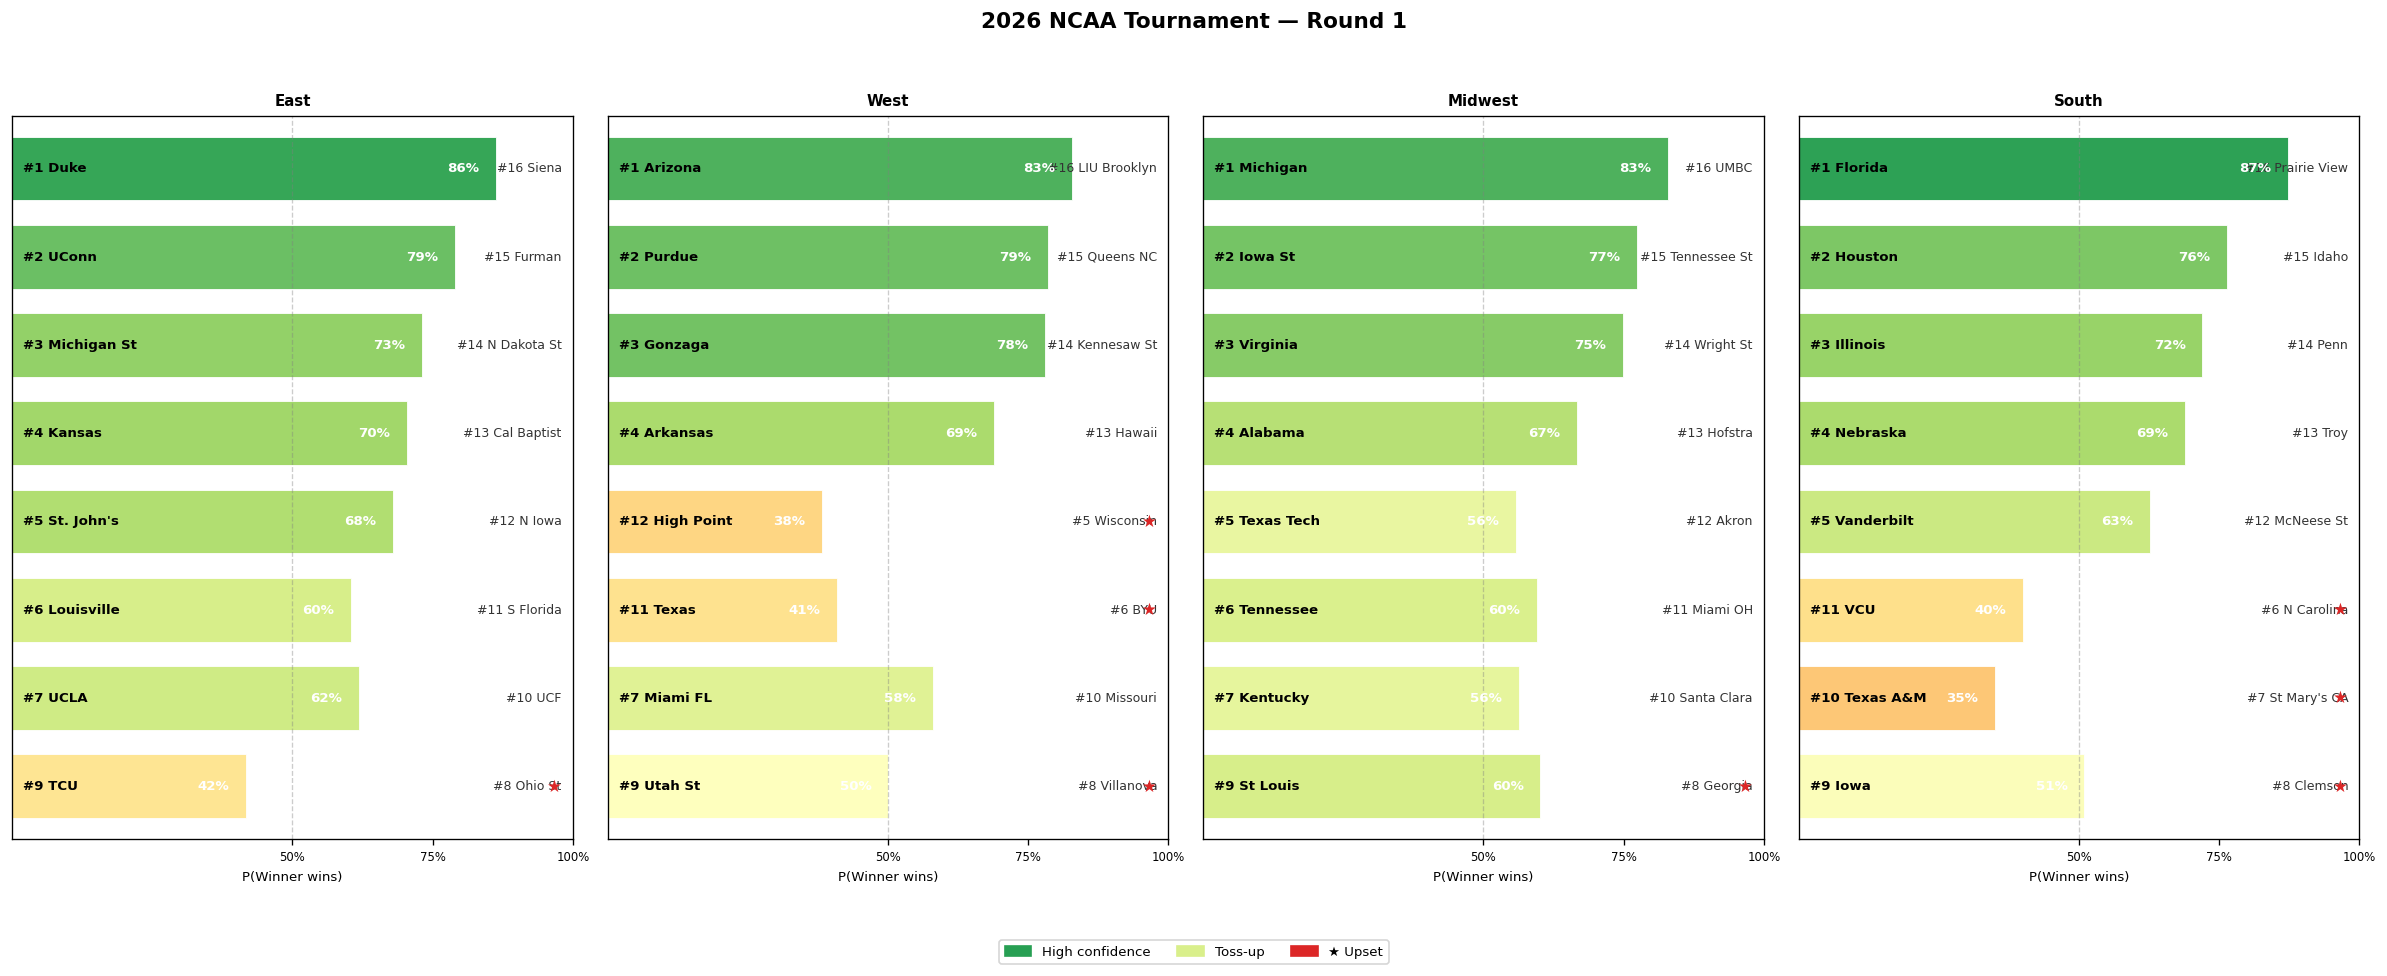

In [5]:
# Build R1 predictions
r1_rows = []
for region, teams in BRACKET_2026.items():
    seed_map = {s:(n,tid) for s,n,tid in teams}
    for s_fav, s_dog in R1_PAIRS:
        fav_name,fav_id = seed_map[s_fav]
        dog_name,dog_id = seed_map[s_dog]
        prob     = predict_matchup(fav_id,s_fav,dog_id,s_dog,feat26,scaler,model)
        fav_won  = R1_FAV_WON.get((region,s_fav),True)
        is_upset = (region,s_dog) in ACTUAL_UPSETS_R1
        r1_rows.append({"Region":region,"FavName":fav_name,"FavID":fav_id,"FavSeed":s_fav,
                         "DogName":dog_name,"DogID":dog_id,"DogSeed":s_dog,
                         "FavProb":prob,"FavWon":fav_won,"ActualUpset":is_upset})
df_r1 = pd.DataFrame(r1_rows)
correct = ((df_r1["FavProb"]>=0.5)==df_r1["FavWon"]).sum()
print(f"Round 1 accuracy: {correct}/{len(df_r1)} ({correct/len(df_r1):.1%})")
plot_round(df_r1, "2026 NCAA Tournament — Round 1", n_rows_per_region=8)


## Round of 32

Round of 32 accuracy: 11/16 (68.8%)


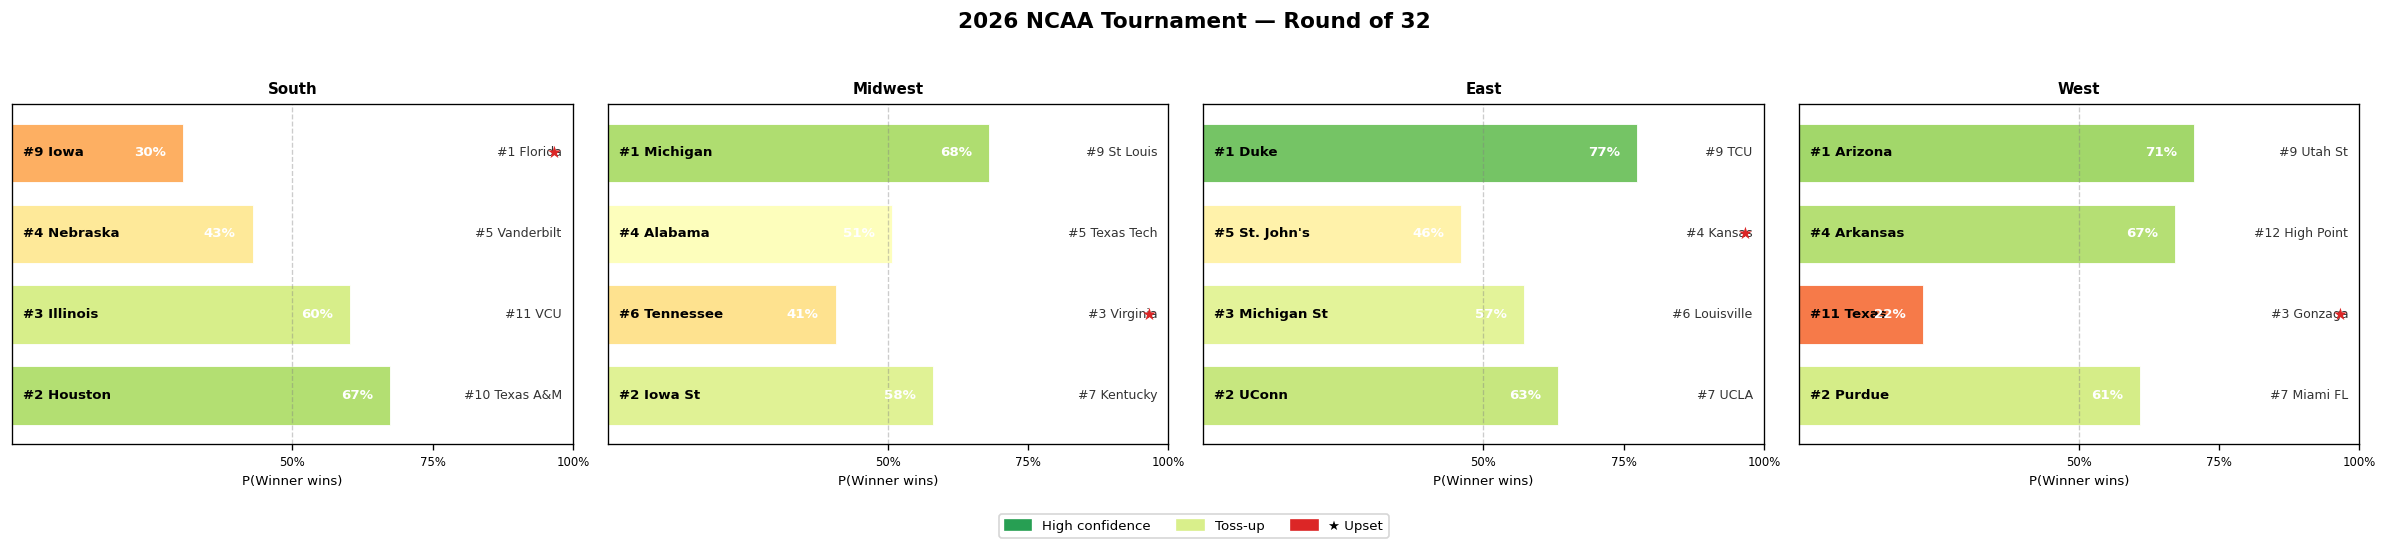

In [6]:
df_r2 = build_round(R2_MATCHUPS, R2_ACTUAL_WINNERS, R2_UPSETS, feat26, scaler, model)
correct = ((df_r2["FavProb"]>=0.5)==df_r2["FavWon"]).sum()
print(f"Round of 32 accuracy: {correct}/{len(df_r2)} ({correct/len(df_r2):.1%})")
plot_round(df_r2, "2026 NCAA Tournament — Round of 32", n_rows_per_region=4)


## Sweet 16

Sweet 16 accuracy: 5/8 (62.5%)


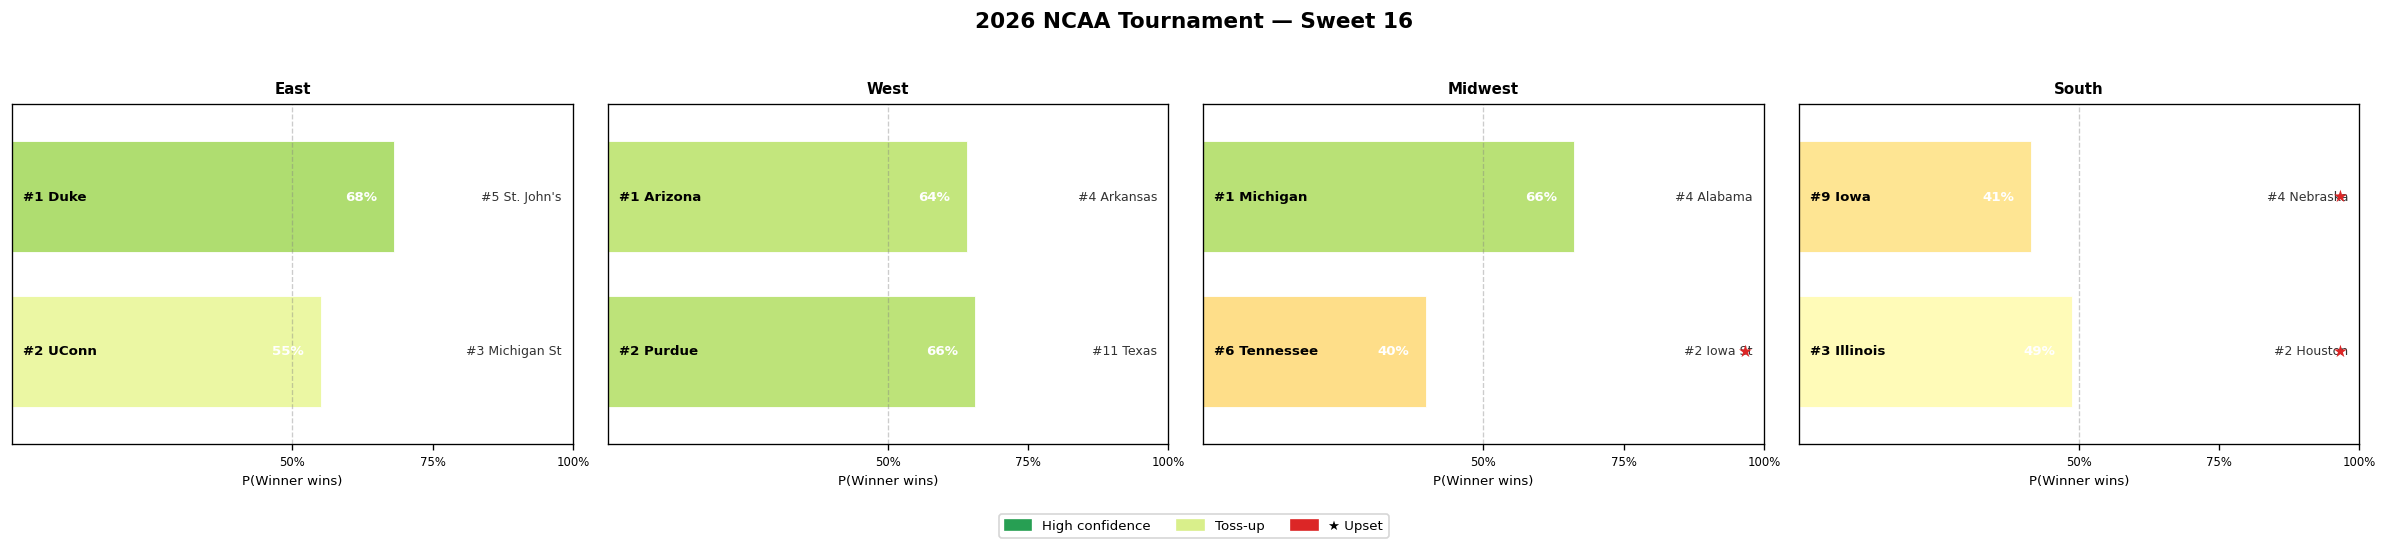

In [7]:
df_s16 = build_round(S16_MATCHUPS, S16_ACTUAL_WINNERS, S16_UPSETS, feat26, scaler, model)
correct = ((df_s16["FavProb"]>=0.5)==df_s16["FavWon"]).sum()
print(f"Sweet 16 accuracy: {correct}/{len(df_s16)} ({correct/len(df_s16):.1%})")
plot_round(df_s16, "2026 NCAA Tournament — Sweet 16", n_rows_per_region=2)


## Elite Eight

Elite Eight accuracy: 3/4 (75.0%)


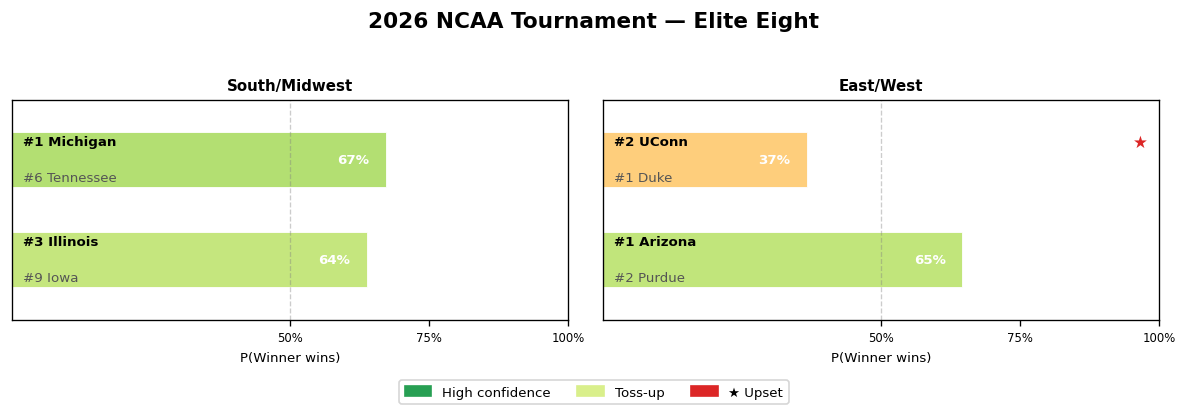

In [8]:
df_e8 = build_round(E8_MATCHUPS, E8_ACTUAL_WINNERS, E8_UPSETS, feat26, scaler, model)
correct = ((df_e8["FavProb"]>=0.5)==df_e8["FavWon"]).sum()
print(f"Elite Eight accuracy: {correct}/{len(df_e8)} ({correct/len(df_e8):.1%})")
plot_round(df_e8, "2026 NCAA Tournament — Elite Eight", late_round=True)


## Final Four

Final Four accuracy: 2/2 (100.0%)


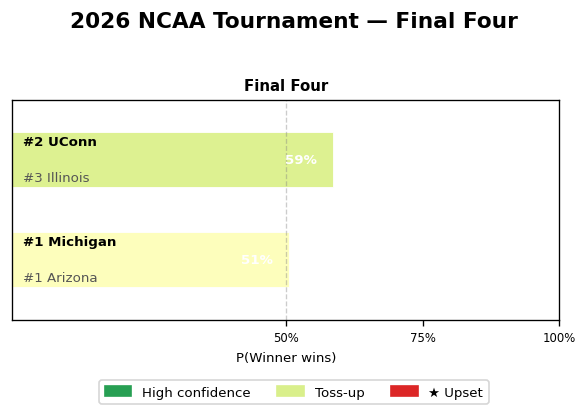

In [9]:
df_ff = build_round(FF_MATCHUPS, FF_ACTUAL_WINNERS, FF_UPSETS, feat26, scaler, model)
correct = ((df_ff["FavProb"]>=0.5)==df_ff["FavWon"]).sum()
print(f"Final Four accuracy: {correct}/{len(df_ff)} ({correct/len(df_ff):.1%})")
plot_round(df_ff, "2026 NCAA Tournament — Final Four", late_round=True)


## Championship

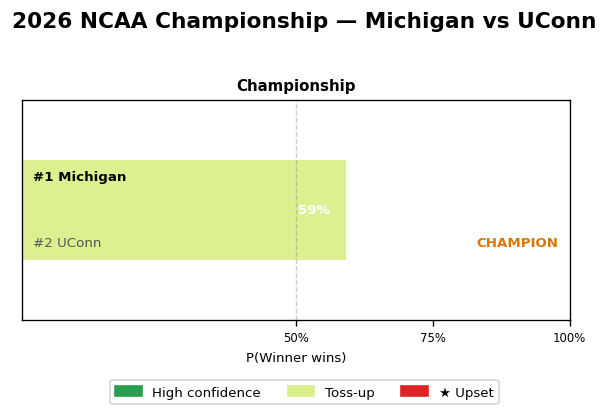

Michigan wins! Model correctly predicted the champion.


In [10]:
df_ch = build_round(CHAMP_MATCHUPS, CHAMP_ACTUAL_WINNERS, CHAMP_UPSETS, feat26, scaler, model)
plot_round(df_ch, "2026 NCAA Championship — Michigan vs UConn", late_round=True)
print("Michigan wins! Model correctly predicted the champion.")


## Overall Tournament Accuracy Summary

In [11]:
summary = [
    ("Round 1",     df_r1),
    ("Round of 32", df_r2),
    ("Sweet 16",    df_s16),
    ("Elite Eight", df_e8),
    ("Final Four",  df_ff),
    ("Championship",df_ch),
]
print(f"{'Round':<15} {'Correct':>8} {'Total':>6} {'Accuracy':>10}")
print("-"*45)
total_c, total_g = 0, 0
for name, df in summary:
    c = ((df["FavProb"]>=0.5)==df["FavWon"]).sum()
    t = len(df)
    total_c += c; total_g += t
    print(f"{name:<15} {c:>8} {t:>6} {c/t:>10.1%}")
print("-"*45)
print(f"{'TOTAL':<15} {total_c:>8} {total_g:>6} {total_c/total_g:>10.1%}")


Round            Correct  Total   Accuracy
---------------------------------------------
Round 1               27     32      84.4%
Round of 32           11     16      68.8%
Sweet 16               5      8      62.5%
Elite Eight            3      4      75.0%
Final Four             2      2     100.0%
Championship           1      1     100.0%
---------------------------------------------
TOTAL                 49     63      77.8%
